## Importing Libraries and Data

In [2]:
# library for loading and preprocessing
import numpy as np
import pandas as pd

# library for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# library for building validation framework
from sklearn.model_selection import train_test_split

# library for data scaling
from sklearn.preprocessing import StandardScaler

# library for computing classification metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# library for ml algorithms
from sklearn.linear_model import LinearRegression, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

# library for hyperparameter tuning
from sklearn.model_selection import GridSearchCV


import warnings 
warnings.filterwarnings("ignore")
seed = 10

In [3]:
# Load data
data = pd.read_csv('water_quality.csv')

# Display first few rows of data
data.head()

,Date,Year,Month,pH,Turbidity (NTU),Conductivity / EC (µS/cm),Temperature (°C),Coagulant Dosage (kg/day)
0,02/01/2011,2011,1,7.32,2209.0,238.2,28.1,1059.8
1,05/01/2011,2011,1,7.44,2583.3,252.8,28.1,946.5
2,09/01/2011,2011,1,7.32,2304.9,224.7,28.1,979.4
3,12/01/2011,2011,1,7.32,2371.9,258.8,28.1,1030.5
4,16/01/2011,2011,1,7.40,3058.3,237.0,28.1,759.7


In [4]:
# Display last few rows of data
data.tail()

,Date,Year,Month,pH,Turbidity (NTU),Conductivity / EC (µS/cm),Temperature (°C),Coagulant Dosage (kg/day)
1339,12/12/2024,2024,12,NaN,NaN,NaN,NaN,NaN
1340,16/12/2024,2024,12,NaN,NaN,NaN,NaN,NaN
1341,19/12/2024,2024,12,NaN,NaN,NaN,NaN,NaN
1342,23/12/2024,2024,12,NaN,NaN,NaN,NaN,NaN
1343,26/12/2024,2024,12,NaN,NaN,NaN,NaN,NaN


In [5]:
# Data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       1344 non-null   object 
 1   Year                       1344 non-null   int64  
 2   Month                      1344 non-null   int64  
 3   pH                         1272 non-null   float64
 4   Turbidity (NTU)            1272 non-null   float64
 5   Conductivity / EC (µS/cm)  1272 non-null   float64
 6   Temperature (°C)           1272 non-null   float64
 7   Coagulant Dosage (kg/day)  1272 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 84.1+ KB


In [6]:
# Check for missing or null values
data.isna().sum()

Date                          0
Year                          0
Month                         0
pH                           72
Turbidity (NTU)              72
Conductivity / EC (µS/cm)    72
Temperature (°C)             72
Coagulant Dosage (kg/day)    72
dtype: int64

In [7]:
# Check for duplicated records
data.duplicated().sum()

np.int64(0)

## Data Cleaning and Validation

In [8]:
data.isna().sum()

Date                          0
Year                          0
Month                         0
pH                           72
Turbidity (NTU)              72
Conductivity / EC (µS/cm)    72
Temperature (°C)             72
Coagulant Dosage (kg/day)    72
dtype: int64

In [9]:
# Remove rows with missing values
data = data.dropna()

data.isna().sum()

Date                         0
Year                         0
Month                        0
pH                           0
Turbidity (NTU)              0
Conductivity / EC (µS/cm)    0
Temperature (°C)             0
Coagulant Dosage (kg/day)    0
dtype: int64

Missing values were dropped since it constituted about 5% of the dataset.

In [10]:
# Rename column names
data.columns = ['date', 'year', 'month', 'ph', 'turbidity',
       'conductivity', 'temperature',
       'coagulant_dosage']

data.head()

,date,year,month,ph,turbidity,conductivity,temperature,coagulant_dosage
0,02/01/2011,2011,1,7.32,2209.0,238.2,28.1,1059.8
1,05/01/2011,2011,1,7.44,2583.3,252.8,28.1,946.5
2,09/01/2011,2011,1,7.32,2304.9,224.7,28.1,979.4
3,12/01/2011,2011,1,7.32,2371.9,258.8,28.1,1030.5
4,16/01/2011,2011,1,7.40,3058.3,237.0,28.1,759.7


In [11]:
# Convert the 'date' column to datetime format
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y')
data.dtypes

date                datetime64[ns]
year                         int64
month                        int64
ph                         float64
turbidity                  float64
conductivity               float64
temperature                float64
coagulant_dosage           float64
dtype: object

#### Data Cleaning and Validation Summary
- Dropped all null values 

- Renamed column headers for readability

- Converted the date variable to datetime dtype

In [ ]:
# Save cleaned data for deployment
data.to_csv('water_quality_cleaned', index=False)

## Data Exploratory Analysis

In [12]:
# Data distribution
data.describe().round(2)

,date,year,month,ph,turbidity,conductivity,temperature,coagulant_dosage
count,1272,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00,1272.00
mean,2017-08-13 23:14:43.018867968,2017.13,6.42,7.16,1863.31,350.32,26.92,658.85
min,2011-01-02 00:00:00,2011.00,1.00,5.95,31.90,24.10,22.10,108.30
25%,2014-04-22 00:00:00,2014.00,3.00,6.94,566.28,237.78,26.10,404.90
50%,2017-08-14 00:00:00,2017.00,6.00,7.20,1331.40,332.80,27.10,625.35
75%,2020-12-06 00:00:00,2020.00,9.00,7.41,2706.98,439.42,28.10,876.08
max,2024-03-26 00:00:00,2024.00,12.00,8.19,14699.40,889.80,33.10,2108.20
std,NaN,3.83,3.48,0.37,1769.46,148.03,1.36,325.00


There is skewness in the turbidity variable suggesting possible outliers

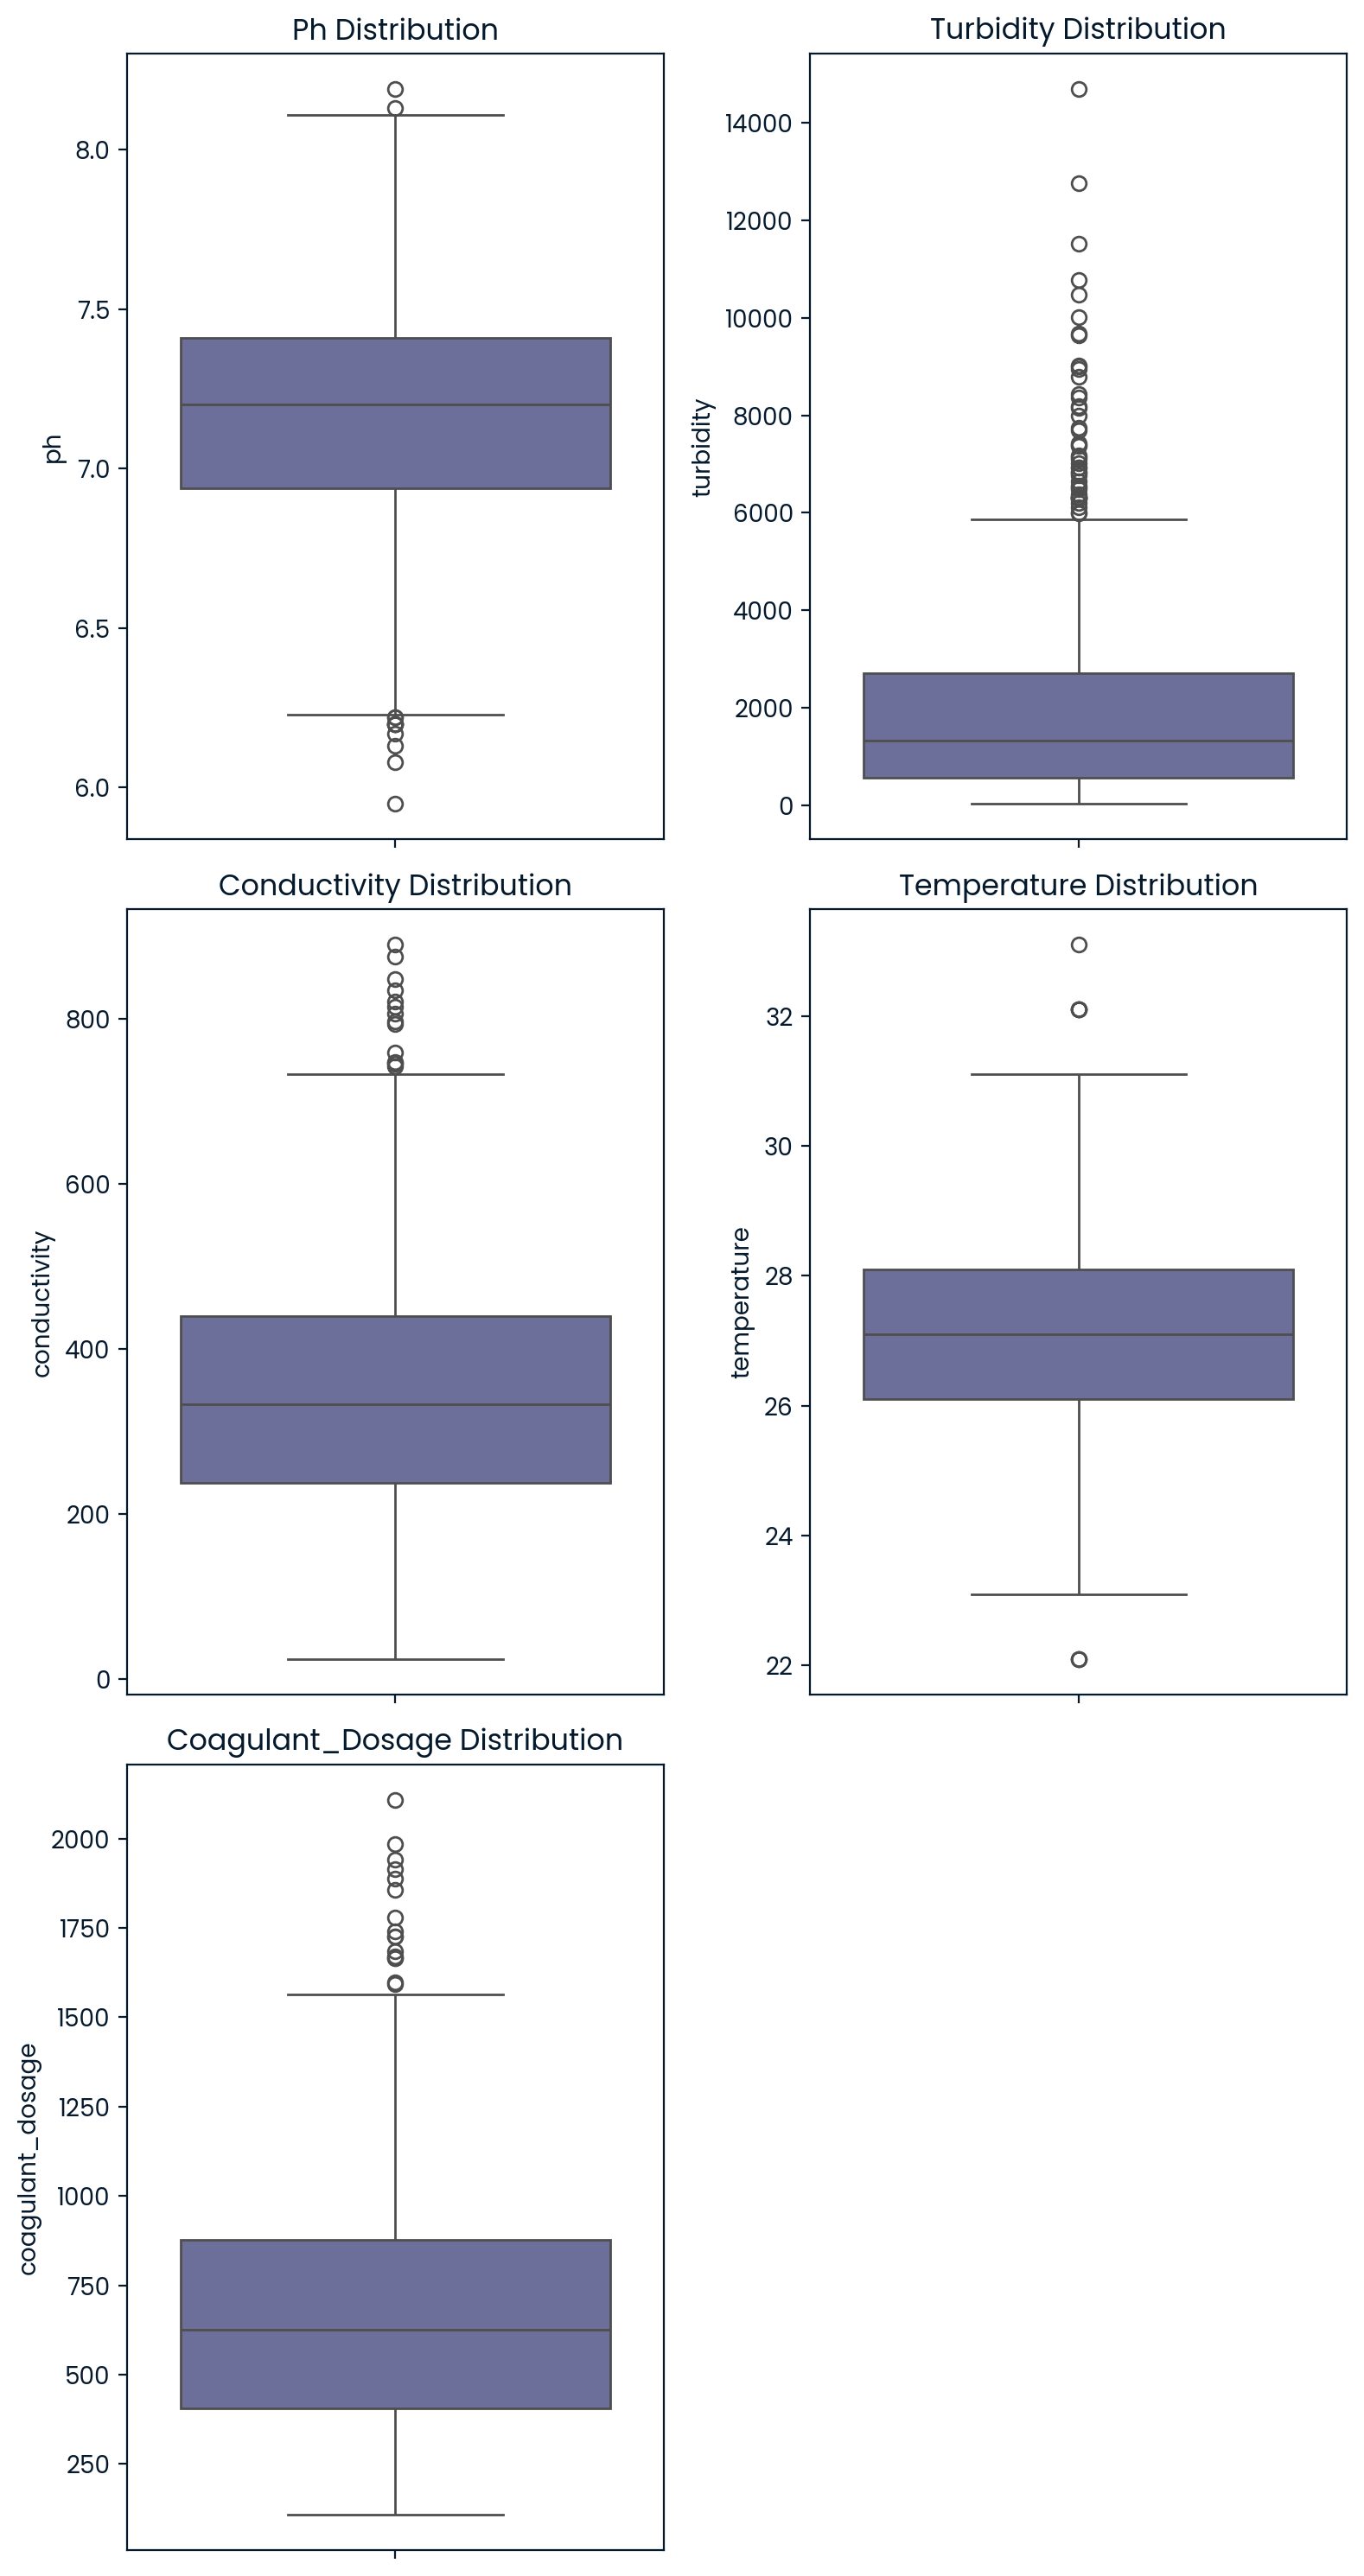

In [13]:
# Investigating skewness with visualization

interest_column = ['ph', 'turbidity', 'conductivity', 'temperature', 'coagulant_dosage']

plt.figure(figsize=(8, 15))
for index, col in enumerate(interest_column):
    plt.subplot(3, 2, index + 1)  # Changed from (2, 2, ...) to (3, 2, ...)
    sns.boxplot(data=data, y=col)
    plt.title(f'{col} Distribution'.title())
plt.tight_layout()
plt.show()

The box plot visualization indicates that there are outliers pH, Turbidity, Conductivity, Temperature, Coagulant_dosage variables. With this, these variables need to be scaled before feeding them into the ML model

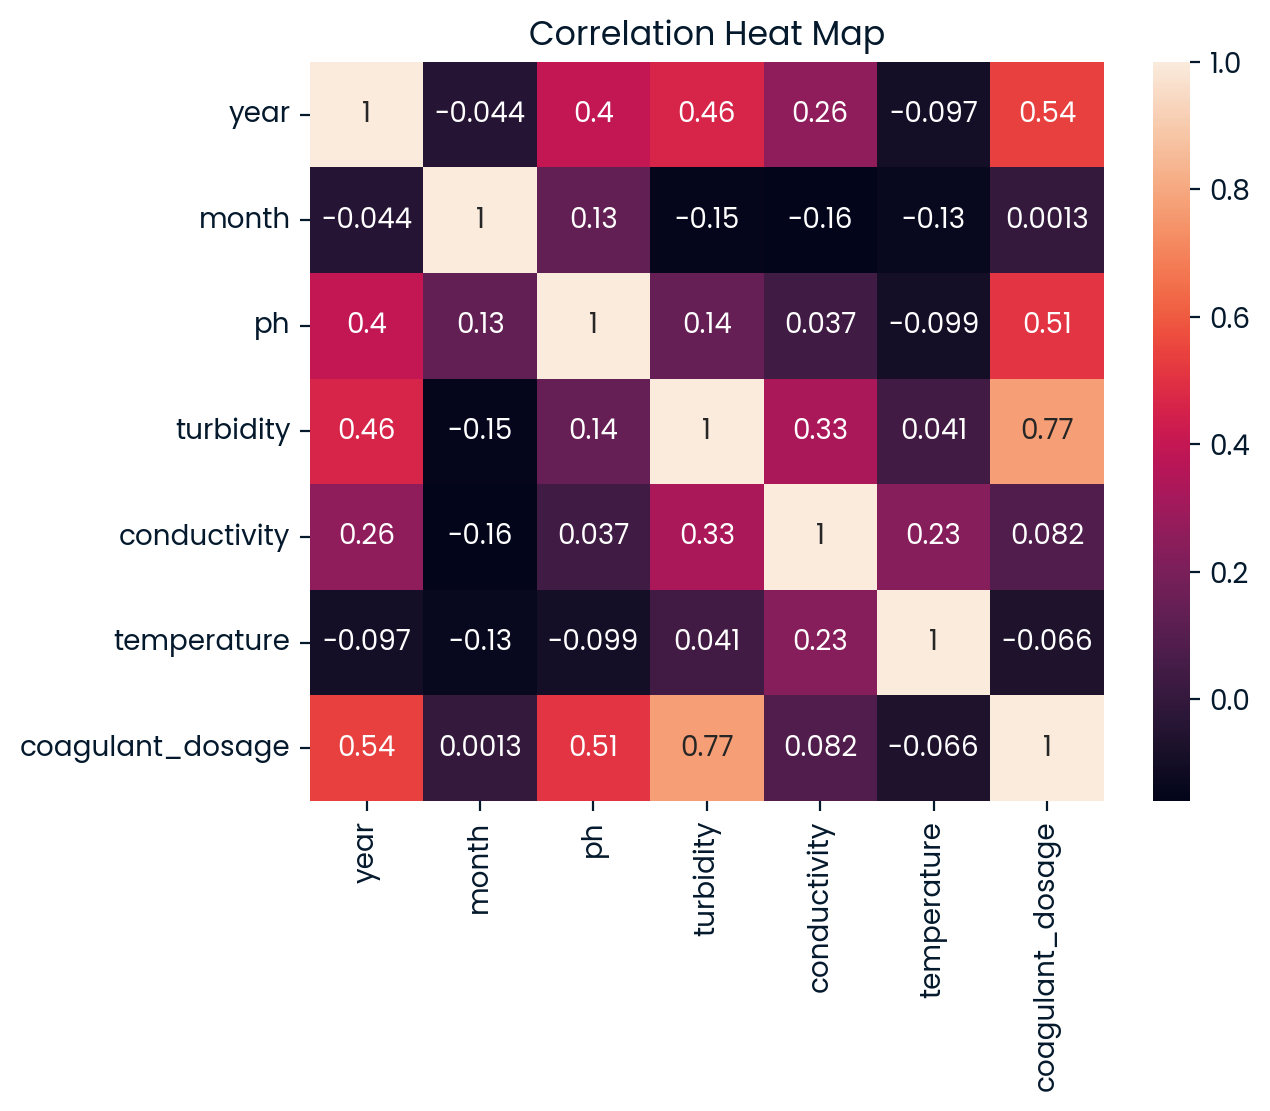

In [14]:
# heatmap correlation
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.title('Correlation Heat Map')
plt.show()

- Turbidity has the highest positive correlation (0.77) with coagulant dosage
- Year and pH have a moderate correlation with coagulant dosage

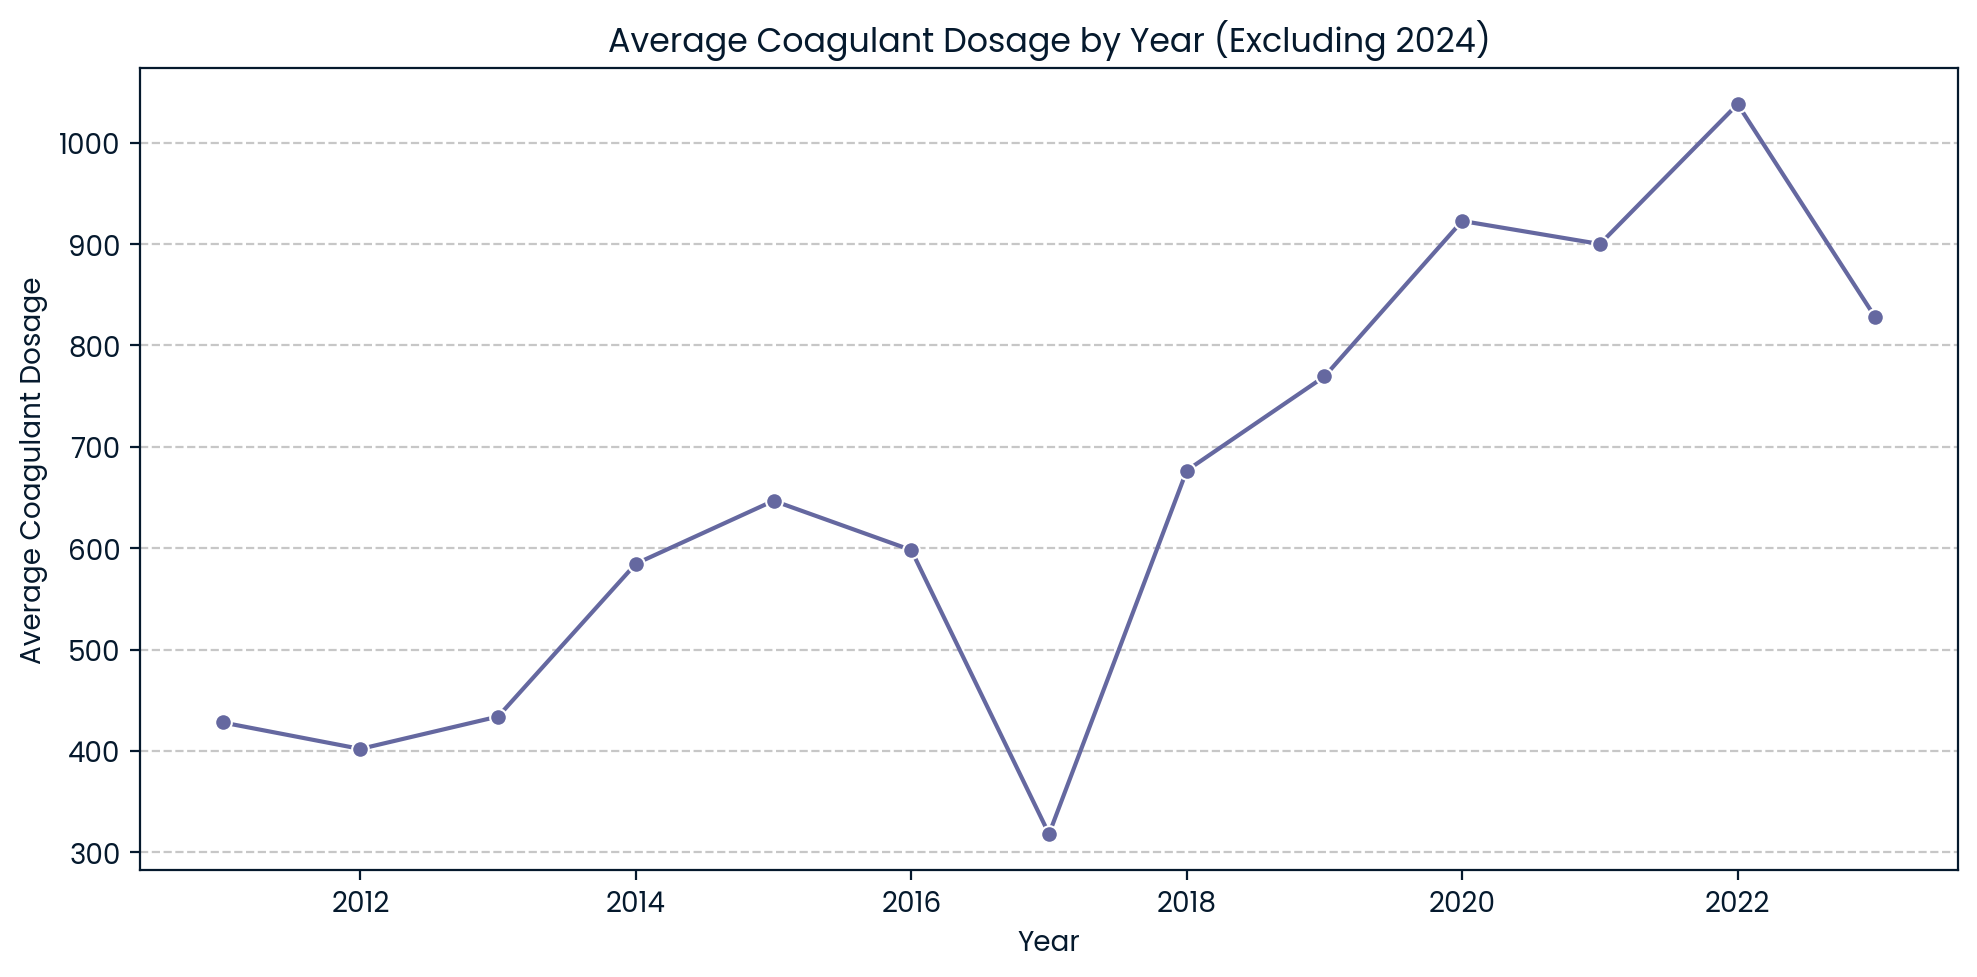

In [15]:
# Investigate further into the correlations

# By Year
# Calculate average coagulant dosage per year
yearly_avg = data.groupby('year')['coagulant_dosage'].mean().reset_index()

# Exclude year 2024
yearly_avg_excl_2024 = yearly_avg[yearly_avg['year'] != 2024]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_avg_excl_2024, x='year', y='coagulant_dosage', marker='o')
plt.xlabel('Year')
plt.ylabel('Average Coagulant Dosage')
plt.title('Average Coagulant Dosage by Year (Excluding 2024)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Coagulant dosage has steady upwards trend with year suggesting water quality decreasing as time goes on

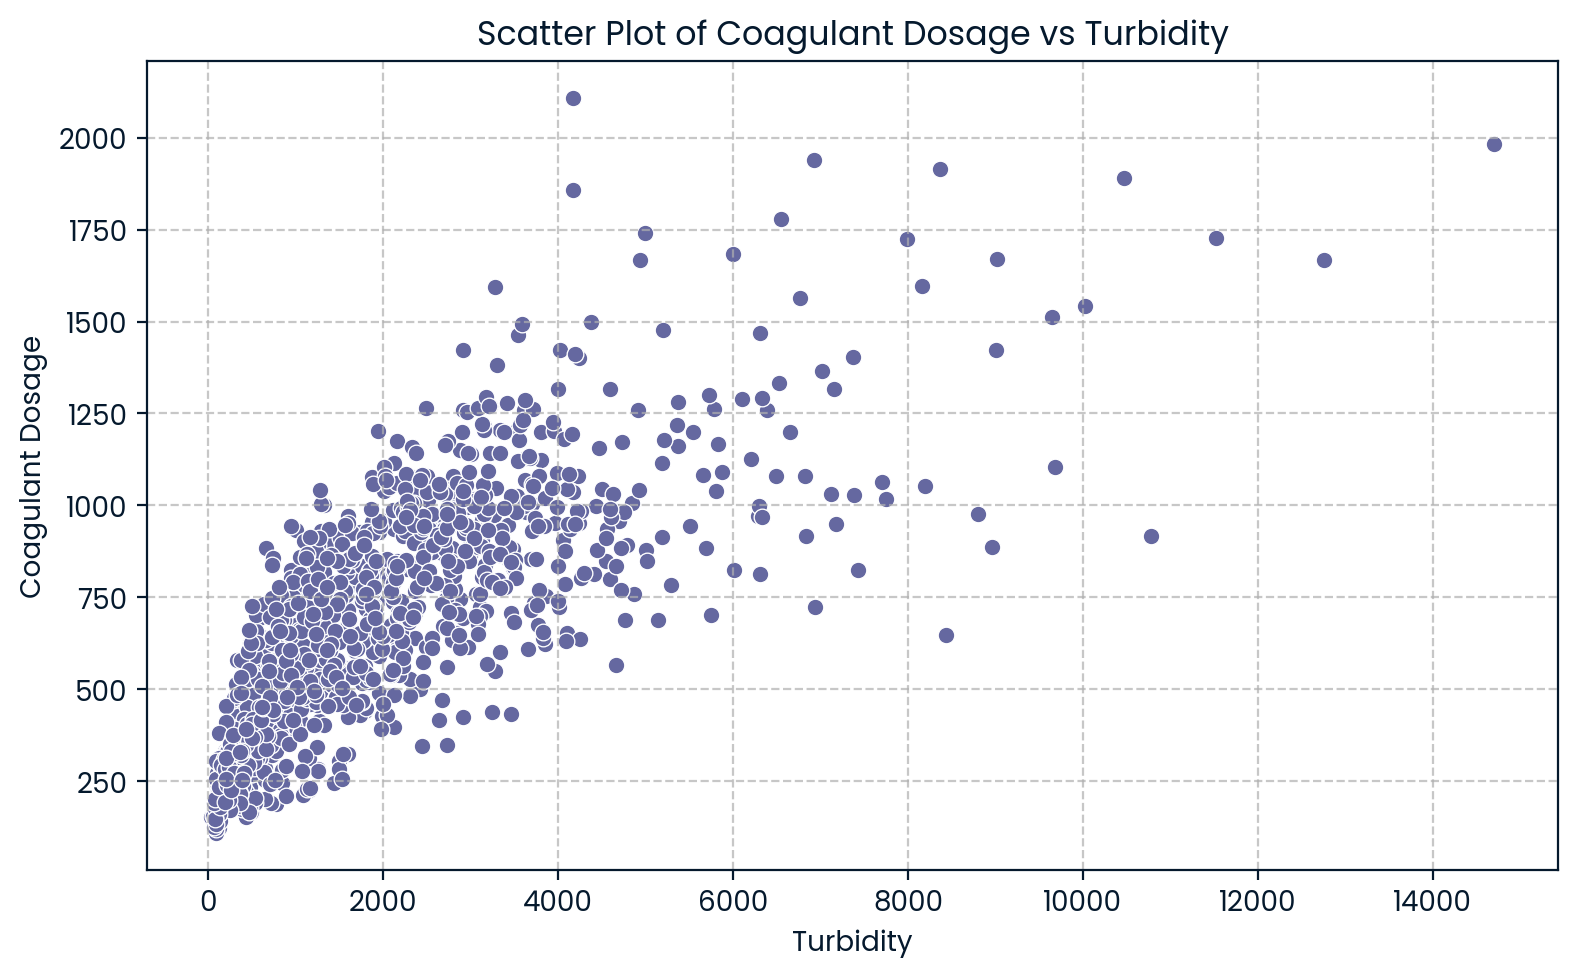

In [16]:
# By Turbidity
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='turbidity', y='coagulant_dosage')
plt.xlabel('Turbidity')
plt.ylabel('Coagulant Dosage')
plt.title('Scatter Plot of Coagulant Dosage vs Turbidity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As turbidity increases with increasing coagulant dosage

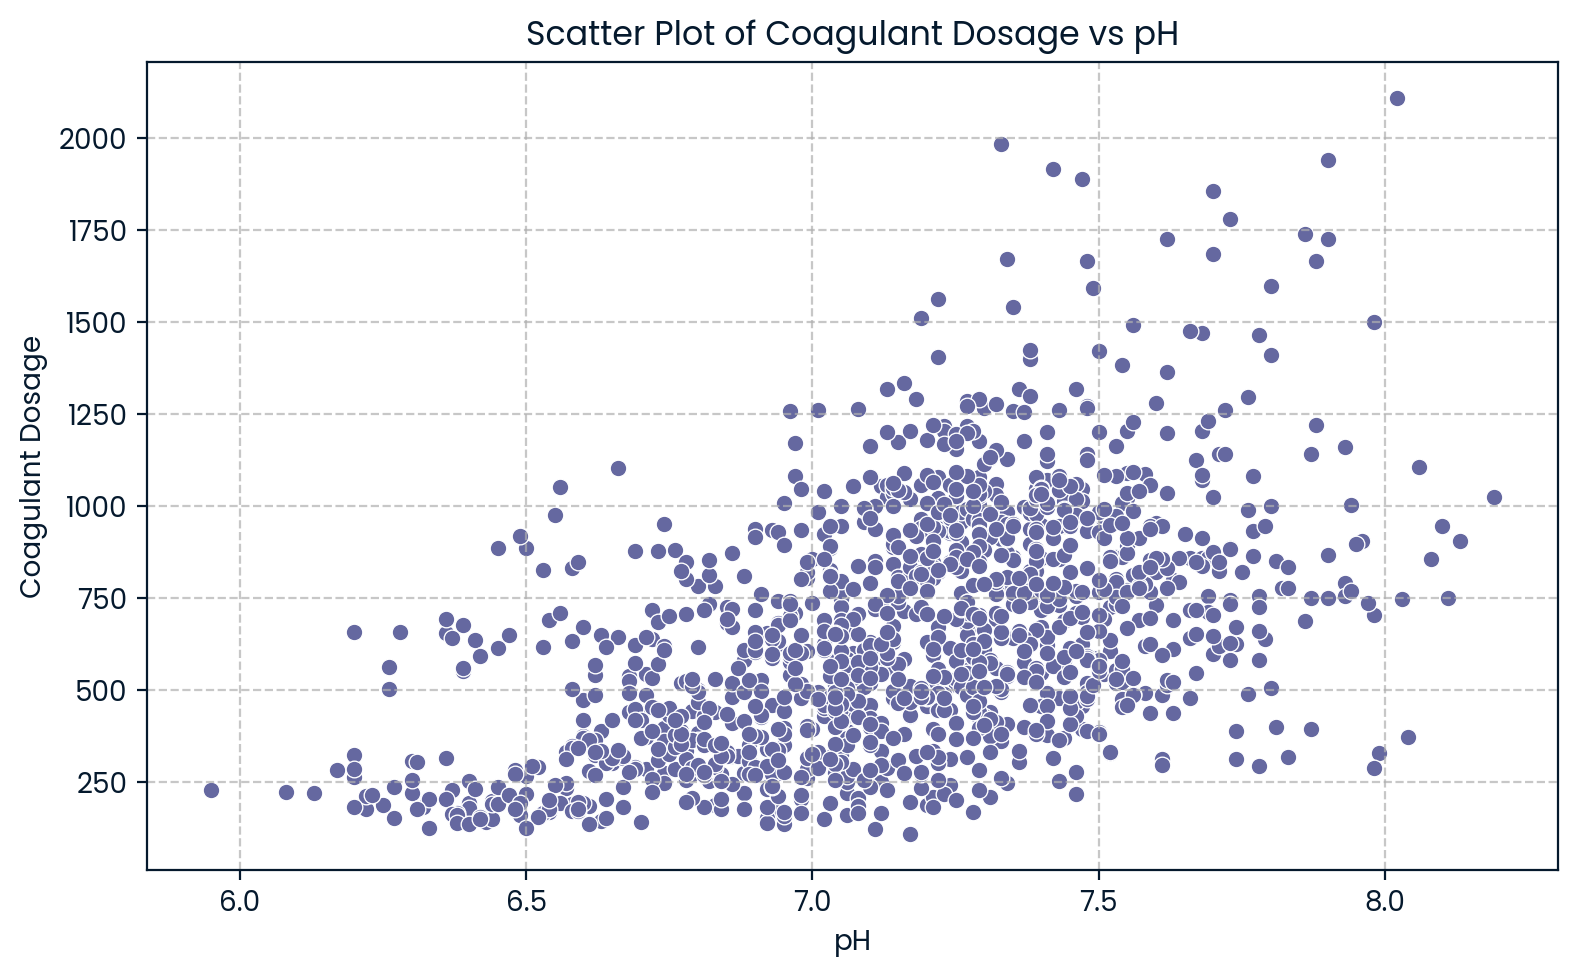

In [17]:
# By pH
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='ph', y='coagulant_dosage')
plt.xlabel('pH')
plt.ylabel('Coagulant Dosage')
plt.title('Scatter Plot of Coagulant Dosage vs pH')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
data.to_csv('water_quality_cleaned.csv', index=False)

There is no strong correlation between pH and coagulant dosage

#### Data Exploratory Analysis Summary
- There is skewness in the pH, Turbidity, Conductivity, Temperature, Coagulant_dosage variables. With this, these variables need to be scaled before feeding them into the ML model 

- There is a strong positive correlation between coagulant dosage and turbidity. pH has a moderate correlation (0.51) with coagulant dosage.

- Coagulant dosage has steady upwards trend with year suggesting water quality decreasing as time goes on

---
## Machine Learning

#### Data Preprocessing

In [19]:
def preprocessing(dataframe, scaler_list: list, drop_list: list):
    """
    Preprocesses the input dataframe by dropping specified columns, scaling selected numerical features,
    and encoding categorical variables.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input dataframe to preprocess.
    scaler_list : list
        List of column names in the dataframe to be scaled using StandardScaler.
    drop_list : list
        List of column names to be dropped from the dataframe.

    Returns
    -------
    pd.DataFrame
        The preprocessed dataframe with specified columns dropped, selected columns scaled,
        and categorical variables one-hot encoded.
    """
    # drop columns
    dataframe.drop(drop_list)
    
    # instantiate scaler
    scaler = StandardScaler()

    # fit transform to model
    dataframe[scaler_list] = scaler.fit_transform(dataframe[scaler_list])

    # encode categorical features
    dataframe = pd.get_dummies(dataframe)

    return dataframe

In [20]:
interest_column = ['ph', 'turbidity', 'conductivity', 'temperature']
drop_column = ['date']

# Fix: Set errors='ignore' to avoid KeyError if 'date' is not present
def preprocessing(dataframe, scaler_list, drop_list):
    """
    Preprocesses the input dataframe by dropping specified columns, scaling selected numerical features,
    and encoding categorical variables.
    """
    # drop columns, ignore error if column not found
    dataframe = dataframe.drop(drop_list, axis=1, errors='ignore')
    
    # instantiate scaler
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    
    # scale selected columns
    dataframe[scaler_list] = scaler.fit_transform(dataframe[scaler_list])
    
    # encode categorical variables if any (example)
    # dataframe = pd.get_dummies(dataframe)
    
    return dataframe

data = preprocessing(data, interest_column, drop_column)
data.head()

,year,month,ph,turbidity,conductivity,temperature,coagulant_dosage
0,2011,1,0.426899,0.195444,-0.757690,0.867195,1059.8
1,2011,1,0.753051,0.407061,-0.659025,0.867195,946.5
2,2011,1,0.426899,0.249662,-0.848922,0.867195,979.4
3,2011,1,0.426899,0.287542,-0.618477,0.867195,1030.5
4,2011,1,0.644334,0.675610,-0.765800,0.867195,759.7


#### Data Splitting

In [21]:
# Dependent variable
X = data.drop('coagulant_dosage', axis=1)

# Target variable
y = data['coagulant_dosage']

# Splitting data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = seed)

#### Model Development

In [22]:
# initiate regression models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Elastic Net': ElasticNet(random_state=10),
    'Random Forest Regressor': RandomForestRegressor(random_state=10, n_jobs=-1),
    'XGBoost Regressor': XGBRegressor(random_state=10, n_jobs=-1, verbosity=0),
    'Huber Regressor': HuberRegressor()
}

def regression_algorithms(X_train, X_test, y_train, y_test):
    """
    Trains and evaluates multiple regression algorithms on the provided data.

    Parameters
    ----------
    X_train : array-like
        Training features.
    X_test : array-like
        Test features.
    y_train : array-like
        Training target values.
    y_test : array-like
        Test target values.

    Returns
    -------
    None
        Displays summary tables of model evaluation metrics (MAE, RMSE, R^2) for both train and test sets.
    """
    print('TRAIN DATA MODEL METRICS')
    summary_train = {'Metric': ['MAE', 'RMSE', 'R^2']}
    
    # Optional: Dictionary to save trained models if needed
    global trained_models
    trained_models = {}

    for name, model in reg_models.items():
        model.fit(X_train, y_train)
        pred_train = model.predict(X_train)
        
        mae = mean_absolute_error(y_train, pred_train)
        rmse = np.sqrt(mean_squared_error(y_train, pred_train))
        r2 = r2_score(y_train, pred_train)
        
        summary_train[name] = [round(mae, 3), round(rmse, 3), round(r2, 3)]

        # saving the model with a valid variable name in a dictionary
        trained_models[name.replace(' ', '_').lower()] = model
    
    table_train = pd.DataFrame(summary_train)
    display(table_train.set_index('Metric').T)
    
    print('\nTEST DATA MODEL METRICS')
    summary_test = {'Metric': ['MAE', 'RMSE', 'R^2']}
    plt.figure(figsize=(20, 10))
    
    for idx, (name, model) in enumerate(reg_models.items()):
        model.fit(X_train, y_train)
        pred_test = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, pred_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred_test))
        r2 = r2_score(y_test, pred_test)
        
        summary_test[name] = [round(mae, 3), round(rmse, 3), round(r2, 3)]
        
        # Optional: Plot predictions vs true values for each model
        plt.subplot(2, 3, idx+1)
        plt.scatter(y_test, pred_test, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title(name)
    
    table_test = pd.DataFrame(summary_test)
    display(table_test.set_index('Metric').T)
    
    plt.tight_layout()
    plt.show()

TRAIN DATA MODEL METRICS


Metric,MAE,RMSE,R^2
Linear Regression,109.377,145.133,0.794
Elastic Net,134.004,174.002,0.703
Random Forest Regressor,30.344,41.587,0.983
XGBoost Regressor,10.526,14.788,0.998
Huber Regressor,110.261,149.251,0.782



TEST DATA MODEL METRICS


Metric,MAE,RMSE,R^2
Linear Regression,114.740,153.042,0.802
Elastic Net,133.395,181.459,0.722
Random Forest Regressor,84.840,116.082,0.886
XGBoost Regressor,89.570,119.786,0.879
Huber Regressor,118.931,160.849,0.782


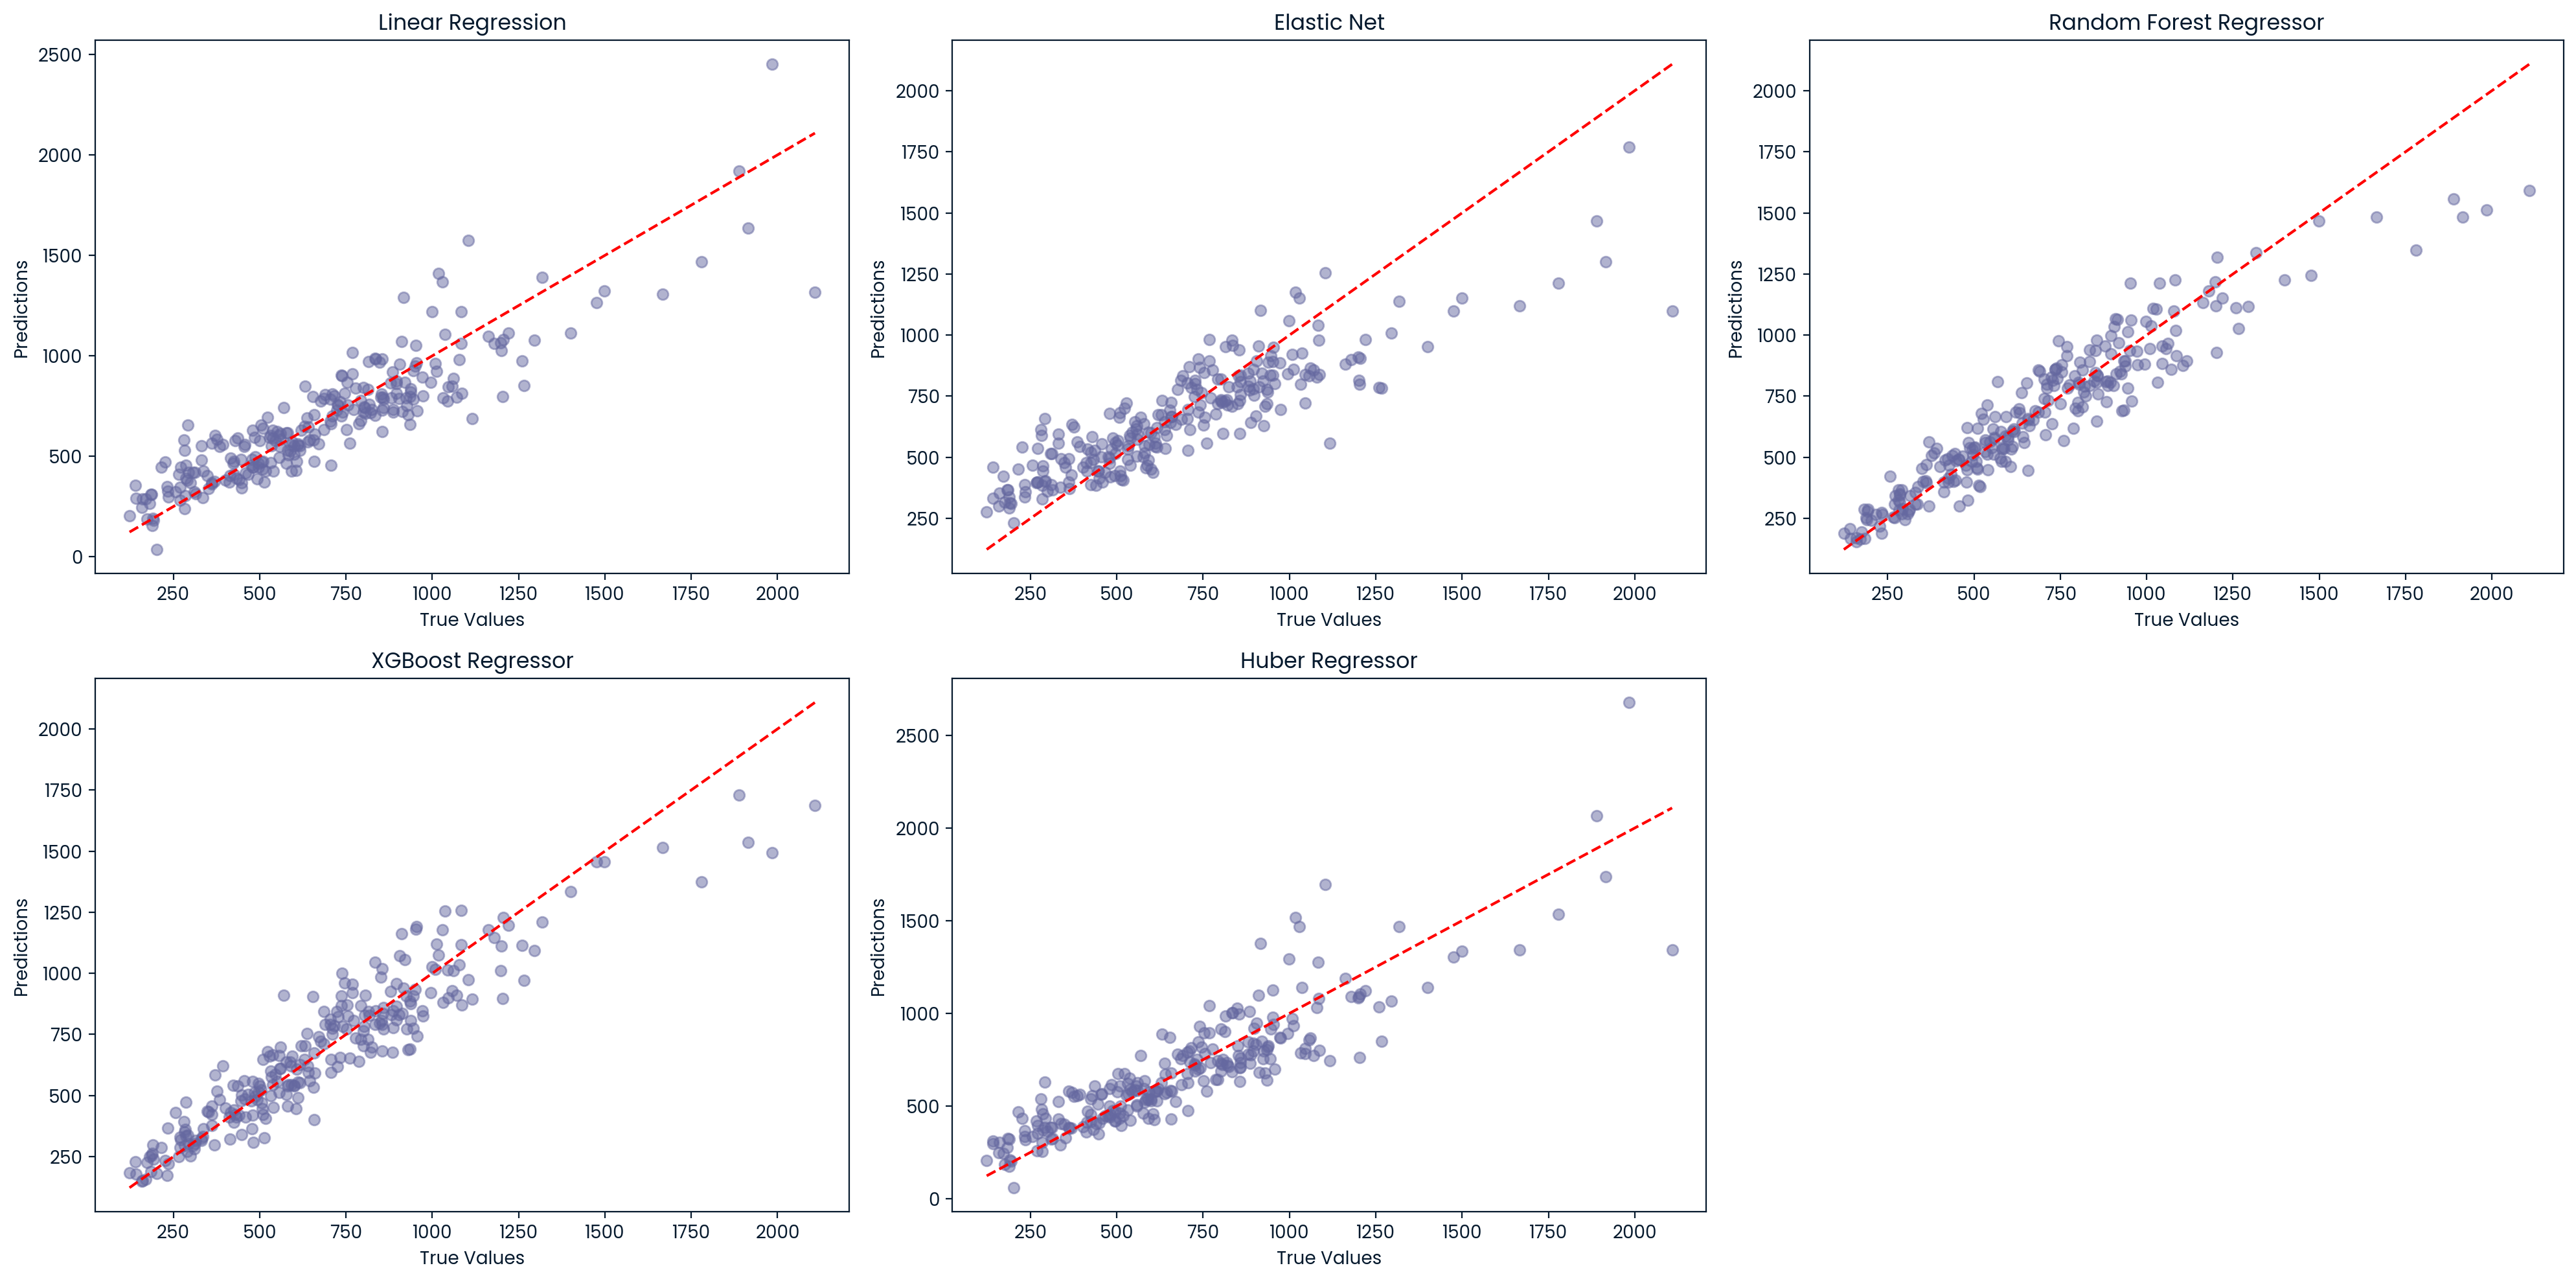

In [23]:
regression_algorithms(X_train, X_test, y_train, y_test)

Neural Network

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import TensorDataset, DataLoader


class SimpleRegressionNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(SimpleRegressionNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.model(x)

def train_pytorch_regressor(X_train, X_test, y_train, y_test, epochs=100, batch_size=32, lr=1e-3, verbose=True):
    """
    Trains and evaluates a simple PyTorch regression neural network.

    Parameters
    ----------
    X_train : array-like
        Training features.
    X_test : array-like
        Test features.
    y_train : array-like
        Training target values.
    y_test : array-like
        Test target values.
    epochs : int
        Number of training epochs.
    batch_size : int
        Batch size for training.
    lr : float
        Learning rate.
    verbose : bool
        Whether to print training progress.

    Returns
    -------
    None
        Displays summary tables of model evaluation metrics (MAE, RMSE, R^2) for both train and test sets.
    """
    # Convert data to torch tensors
    X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)
    X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
    y_test_tensor = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

    # DataLoader for batching
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model, loss, optimizer
    input_dim = X_train_tensor.shape[1]
    model = SimpleRegressionNN(input_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        if verbose and (epoch+1) % (epochs//5) == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader.dataset):.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        pred_train = model(X_train_tensor).numpy().flatten()
        pred_test = model(X_test_tensor).numpy().flatten()

    # Metrics
    summary_train = {
        'MAE': round(mean_absolute_error(y_train, pred_train), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_train, pred_train)), 3),
        'R^2': round(r2_score(y_train, pred_train), 3)
    }
    summary_test = {
        'MAE': round(mean_absolute_error(y_test, pred_test), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_test)), 3),
        'R^2': round(r2_score(y_test, pred_test), 3)
    }

    # Display metrics
    print('TRAIN DATA MODEL METRICS')
    table_train = pd.DataFrame([summary_train], index=['PyTorch NN'])
    display(table_train)

    print('\nTEST DATA MODEL METRICS')
    table_test = pd.DataFrame([summary_test], index=['PyTorch NN'])
    display(table_test)

    # Plot predictions vs true values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, pred_test, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('PyTorch NN: Predictions vs True Values (Test Set)')
    plt.tight_layout()
    plt.show()

Epoch 20/100, Loss: 101779.7408
Epoch 40/100, Loss: 101415.3754
Epoch 60/100, Loss: 99442.1939
Epoch 80/100, Loss: 97249.0028
Epoch 100/100, Loss: 91734.1412
TRAIN DATA MODEL METRICS


,MAE,RMSE,R^2
PyTorch NN,247.568,302.045,0.106



TEST DATA MODEL METRICS


,MAE,RMSE,R^2
PyTorch NN,248.893,324.855,0.11


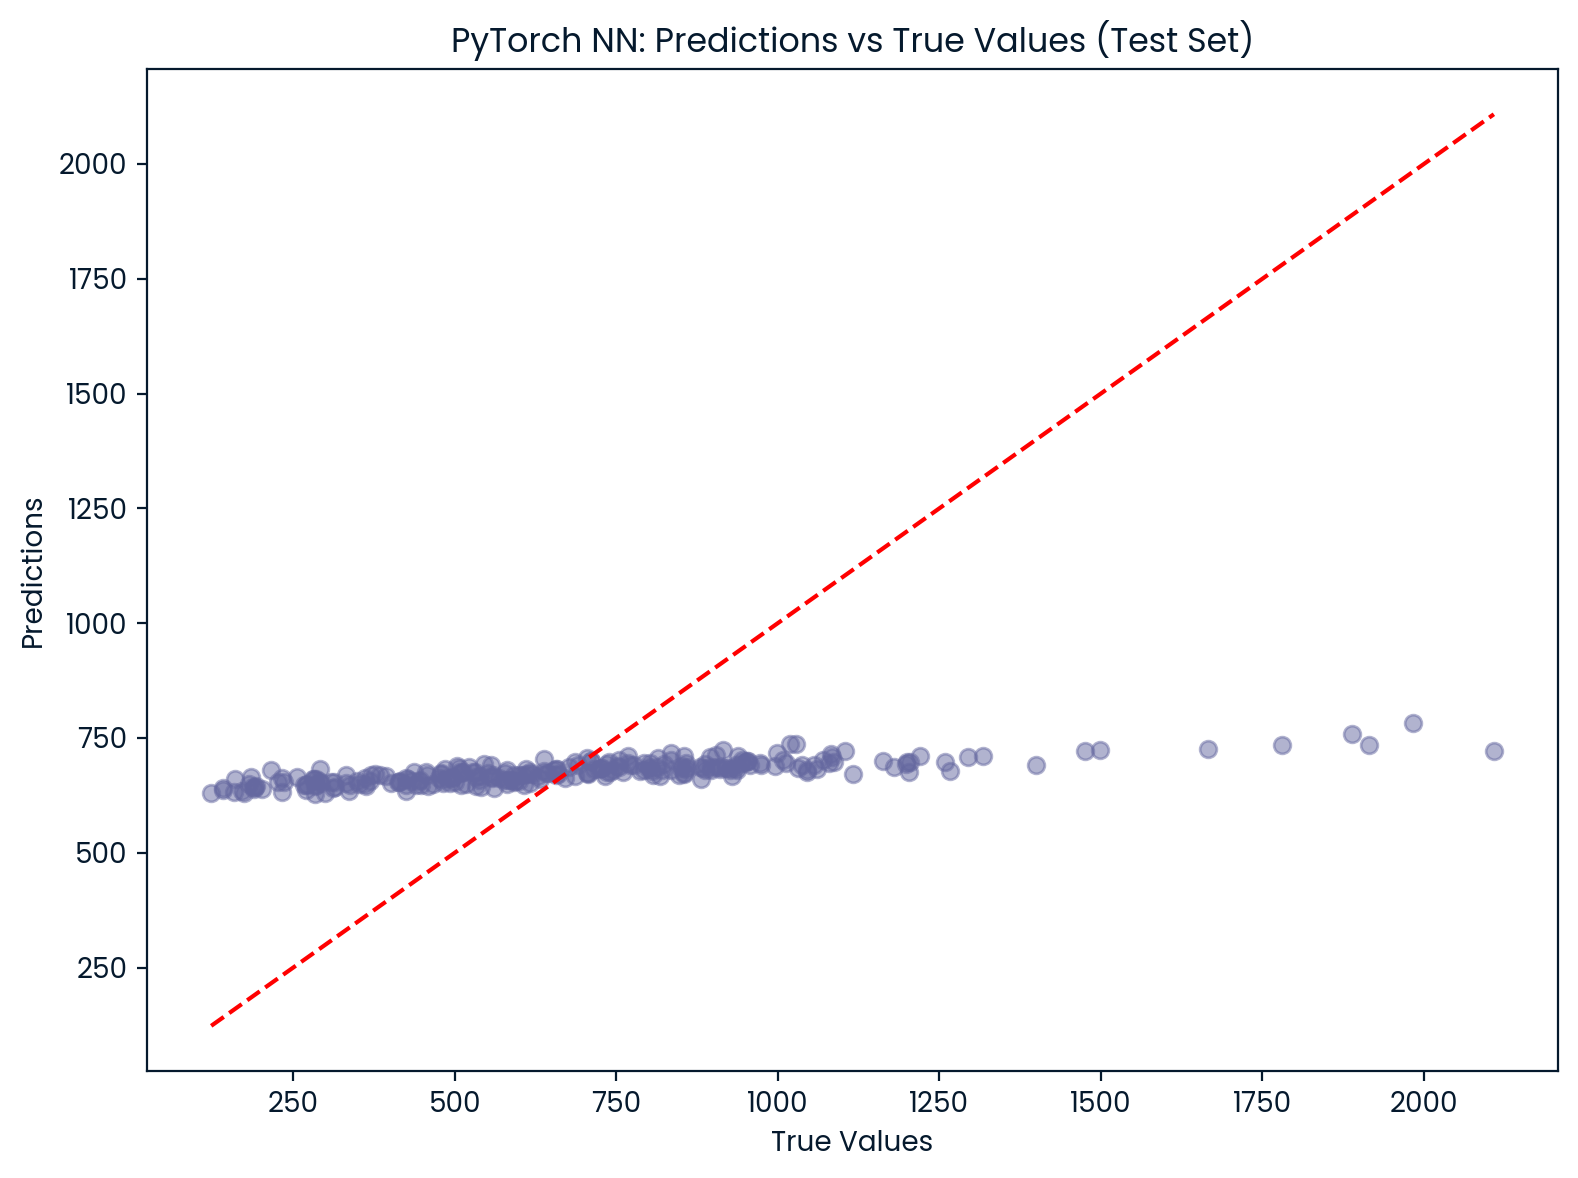

In [25]:
train_pytorch_regressor(X_train, X_test, y_train, y_test)

#### Model Selection

- Artificial Neural Network, Linear Regression, Elastic Net, and Huber Regressor performed well with R-squared above 70%.
- XGBoost overfitted the dataset meaning it can't generalise well to unseen data.
- Random Forest is the selected model because it had the highest R-squared score (88.6%) with the least Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) scores.

#### Hyperparameter Tuning

In [26]:
# Define the base estimator
rf = RandomForestRegressor(random_state=seed)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Best R-squared score and parameters
best_r2 = grid_search.best_score_
best_params = grid_search.best_params_

print(f'Best R-squared Score: {best_r2}')
print(f'Best Parameters: {best_params}')

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n

No significant effect after the hyper-parameter tuning

#### Machine Learning Summary
1. Data Processing
    - Date column was dropped
    - Standard Scaler was used to scale the skewed nutritional information columns for model training

2. Data Splitting
    - Data was splitted into 80% for training and 20% for testing/ validation

3. Model Training and Evaluation
    - Six regression models were trained and Random Forest Regressor model was selected because it had the highest R-squared score with the least Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) scores

4. Hyperparameter Tuning
    - Used GridSearchCV to tune the model. No added accuracy performance was achieved